In [559]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from scipy.stats import chi2

In [560]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
RESULT_FOLDER = DISEASE_FOLDER + "leiden_results"

# pick community index by DGIDB genes

In [561]:
with open("../output/disease_to_comm_dgidb_gene_count.json", "r") as f:
    disease_to_comm_dgidb_gene_count = json.load(f)

In [562]:
disease_to_comm_dgidb_gene_count = disease_to_comm_dgidb_gene_count[DISEASE]

In [563]:
disease_to_comm_dgidb_gene_count

{'0': 4,
 '1': 5,
 '2': 0,
 '3': 26,
 '4': 0,
 '5': 0,
 '6': 4,
 '7': 3,
 '8': 10,
 '9': 0,
 '10': 0}

In [564]:
idx = [int(u) for u in disease_to_comm_dgidb_gene_count.keys() if disease_to_comm_dgidb_gene_count[u] > 0]

# important terms processing

In [565]:
with open(f"{RESULT_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [566]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [567]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [568]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,GO_ID,Slim_IDs,Overlap (value),KEGG_ID
0,1,1241,Bounding Membrane Of Organelle (GO:0098588),113/819,1.770389e-13,['cellular anatomical structure'],GO_Cellular_Component_2023,5.447351e-16,0.0,0.0,2.561616,90.031150,SCARB2;GALNT12;GALNT11;GALNT14;GALNT13;PGAP2;K...,GO:0098588,{'GO:0110165'},0.137973,NaN
1,1,1241,Membrane Trafficking R-HSA-199991,92/599,4.294773e-13,['Vesicle-mediated transport'],Reactome_2022,4.608126e-16,0.0,0.0,2.882507,101.791510,ITSN2;SCARB2;DENND1B;SCOC;C2CD5;KDELR1;DENND1A...,NaN,NaN,0.153589,NaN
2,1,1241,Golgi Vesicle Transport (GO:0048193),47/197,2.020861e-12,"['localization', 'cellular process']",GO_Biological_Process_2023,6.178113e-16,0.0,0.0,4.883434,171.019555,NBAS;LMAN2L;SAR1A;KDELR1;PEF1;PITPNB;BICD2;STX...,GO:0048193,"{'GO:0051179', 'GO:0009987'}",0.238579,NaN
3,1,1241,Vesicle-mediated Transport R-HSA-5653656,92/637,9.993430e-12,['Vesicle-mediated transport'],Reactome_2022,2.144513e-14,0.0,0.0,2.675942,84.220656,ITSN2;SCARB2;DENND1B;SCOC;C2CD5;KDELR1;DENND1A...,NaN,NaN,0.144427,NaN
4,1,1241,Post-translational Protein Modification R-HSA-...,152/1383,5.215519e-10,['Metabolism of proteins'],Reactome_2022,1.678815e-12,0.0,0.0,1.987422,53.884830,GALNT12;GALNT11;GALNT14;KDELR1;GALNT18;SMC6;UB...,NaN,NaN,0.109906,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1086,9,144,Keratin Filament (GO:0045095),12/39,8.056405e-16,['cellular anatomical structure'],GO_Cellular_Component_2023,4.028203e-17,0.0,0.0,66.764310,2520.394508,KRT82;KRT36;KRT79;KRT78;KRT77;KRT76;KRT86;KRT7...,GO:0045095,{'GO:0110165'},0.307692,NaN
1087,9,144,Epidermis Development (GO:0008544),13/85,6.111026e-13,['developmental process'],GO_Biological_Process_2023,3.819391e-14,0.0,0.0,27.268024,842.475597,KRTDAP;SPRR2F;KRTAP5-9;SPRR2G;KLK14;KRT32;KRT3...,GO:0008544,{'GO:0032502'},0.152941,NaN
1088,9,144,Staphylococcus aureus infection,13/95,6.788863e-13,['Infectious disease: bacterial'],KEGG_2021_Human,1.697216e-13,0.0,0.0,23.930553,703.668746,KRT24;KRT35;KRT32;KRT31;KRT40;KRT33A;KRT28;KRT...,NaN,NaN,0.136842,hsa05150
1089,9,144,Intermediate Filament (GO:0005882),12/69,7.559289e-13,['cellular anatomical structure'],GO_Cellular_Component_2023,7.559289e-14,0.0,0.0,31.577352,954.059629,KRT82;KRT36;KRT79;KRT78;KRT77;KRT76;KRT75;KRT8...,GO:0005882,{'GO:0110165'},0.173913,NaN


In [569]:
max_idx = important_terms["Community Index"].value_counts().idxmax()

In [570]:
max_idx

2

In [571]:
olfactory_idx  = important_terms.loc[important_terms["Adjusted P-value"].idxmin(), "Community Index"]

In [572]:
olfactory_idx

8

# Community Category df

In [573]:
df = important_terms

# ---------------------------------------------------
# 1. Parse Category column (stringified list) -> list
# ---------------------------------------------------
df["Category"] = df["Category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# ---------------------------------------------------
# 2. Explode: one category per row
# ---------------------------------------------------
df_exp = df.explode("Category").reset_index(drop=True)

# ---------------------------------------------------
# 3. Parse Overlap "a/b" into numerator and denominator
# ---------------------------------------------------
def parse_overlap(s):
    try:
        a, b = s.split("/")
        return int(a), int(b)
    except Exception:
        return 0, 0

overlap_nums = []
overlap_dens = []

for s in df_exp["Overlap"]:
    a, b = parse_overlap(s)
    overlap_nums.append(a)
    overlap_dens.append(b)

df_exp["Overlap_num"] = overlap_nums
df_exp["Overlap_den"] = overlap_dens

# ---------------------------------------------------
# 4. Total number of terms per community
# ---------------------------------------------------
total_terms = (
    df_exp.groupby("Community Index")["Term"]
          .nunique()
)

# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
# ---------------------------------------------------
# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
#    - fisher_p = Fisher-combined p-value over terms in that category
# ---------------------------------------------------
def fisher_method(pvals):
    p = pd.Series(pvals).dropna().astype(float)
    if len(p) == 0:
        return np.nan

    # avoid log(0)
    p = p.clip(lower=1e-300)

    stat = -2.0 * np.sum(np.log(p))
    df = 2 * len(p)
    return float(chi2.sf(stat, df))

agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
        fisher_p=("Adjusted P-value", fisher_method),  # <-- change column name if needed
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]

# ---------------------------------------------------
# 6. Add total_terms_in_comm and frac_of_comm
# ---------------------------------------------------
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

# ---------------------------------------------------
# 7. Final output df
# ---------------------------------------------------
community_categories = agg[[
    "Community Index",
    "Category",
    "count",
    "Gross Overlap",
    "fisher_p",
    "total_terms_in_comm",
    "frac_of_comm",
]]


community_categories = community_categories.sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

community_categories


,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm
0,1,cellular process,26,0.175986,1.865795e-85,98,0.265306
1,1,cellular anatomical structure,22,0.139365,5.322545e-93,98,0.224490
2,1,localization,21,0.188844,1.007734e-71,98,0.214286
3,1,biological regulation,9,0.242248,3.369944e-21,98,0.091837
4,1,Vesicle-mediated transport,6,0.165684,5.726126e-37,98,0.061224
...,...,...,...,...,...,...,...
81,9,Developmental Biology,3,0.194096,0.000000e+00,9,0.333333
82,9,cellular anatomical structure,3,0.214765,6.531227e-33,9,0.333333
83,9,Infectious disease: bacterial,1,0.136842,6.788863e-13,9,0.111111
84,9,cellular process,1,0.367647,2.978273e-35,9,0.111111


In [574]:
community_categories["fisher_score"] = -np.log10(
    community_categories["fisher_p"].clip(lower=1e-300)
)

community_categories["fisher_z"] = (
    community_categories
    .groupby("Community Index")["fisher_score"]
    .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)


In [575]:
community_categories

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_z
0,1,cellular process,26,0.175986,1.865795e-85,98,0.265306,84.729136,2.134844
1,1,cellular anatomical structure,22,0.139365,5.322545e-93,98,0.224490,92.273881,2.395736
2,1,localization,21,0.188844,1.007734e-71,98,0.214286,70.996654,1.659983
3,1,biological regulation,9,0.242248,3.369944e-21,98,0.091837,20.472377,-0.087114
4,1,Vesicle-mediated transport,6,0.165684,5.726126e-37,98,0.061224,36.242139,0.458194
...,...,...,...,...,...,...,...,...,...
81,9,Developmental Biology,3,0.194096,0.000000e+00,9,0.333333,300.000000,1.992710
82,9,cellular anatomical structure,3,0.214765,6.531227e-33,9,0.333333,32.185005,-0.413613
83,9,Infectious disease: bacterial,1,0.136842,6.788863e-13,9,0.111111,12.168203,-0.593464
84,9,cellular process,1,0.367647,2.978273e-35,9,0.111111,34.526035,-0.392579


## heatmap

In [576]:
if max_idx in idx:
    idx.remove(max_idx)
if olfactory_idx in idx:
    idx.remove(olfactory_idx)

In [577]:
idx

[0, 1, 3, 6, 7]

In [578]:
community_categories_filtered = community_categories[community_categories["Community Index"].isin(idx)]

In [579]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_z
0,1,cellular process,26,0.175986,1.865795e-85,98,0.265306,84.729136,2.134844
1,1,cellular anatomical structure,22,0.139365,5.322545e-93,98,0.224490,92.273881,2.395736
2,1,localization,21,0.188844,1.007734e-71,98,0.214286,70.996654,1.659983
3,1,biological regulation,9,0.242248,3.369944e-21,98,0.091837,20.472377,-0.087114
4,1,Vesicle-mediated transport,6,0.165684,5.726126e-37,98,0.061224,36.242139,0.458194
5,1,Metabolism of RNA,4,0.183807,1.770952e-11,98,0.040816,10.751793,-0.423246
6,1,Glycan biosynthesis and metabolism,3,0.285714,5.436907e-09,98,0.030612,8.264648,-0.509250
7,1,Metabolism,3,0.255034,1.467660e-08,98,0.030612,7.833375,-0.524163
8,1,Metabolism of proteins,3,0.120284,3.349266e-15,98,0.030612,14.475050,-0.294498
9,1,Autophagy,2,0.181818,1.337610e-06,98,0.020408,5.873670,-0.591929


In [580]:
heat_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="fisher_z"
)


In [581]:
label_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="count"
)

In [582]:
heat_df

Community Index,1,3
Category,,
Autophagy,-0.591929,NaN
Cellular responses to stimuli,-0.654044,NaN
Extracellular matrix organization,NaN,-0.486410
"Folding, sorting and degradation",-0.689681,NaN
Gene expression (Transcription),-0.665041,NaN
Glycan biosynthesis and metabolism,-0.509250,NaN
Hemostasis,NaN,-0.721520
Immune System,NaN,-0.659073
Lipid metabolism,-0.579562,NaN


In [583]:
label_df

Community Index,1,3
Category,,
Autophagy,2.0,NaN
Cellular responses to stimuli,1.0,NaN
Extracellular matrix organization,NaN,4.0
"Folding, sorting and degradation",1.0,NaN
Gene expression (Transcription),1.0,NaN
Glycan biosynthesis and metabolism,3.0,NaN
Hemostasis,NaN,1.0
Immune System,NaN,1.0
Lipid metabolism,1.0,NaN


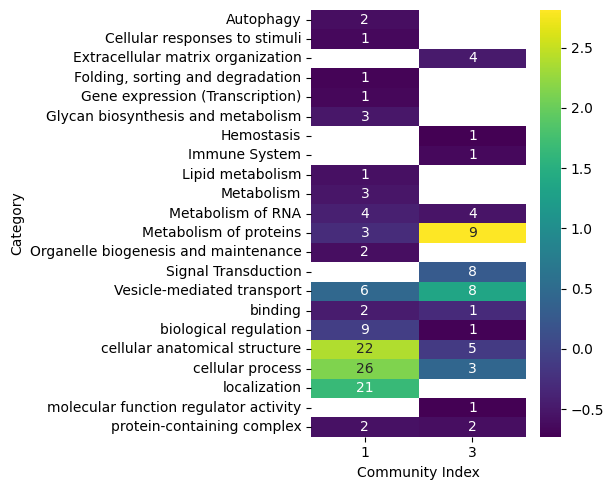

In [584]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=label_df,   # <-- use count for labels
    fmt=".0f",        # integer labels
    cbar=True
)

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/category_gross_overlap_heatmap.png", bbox_inches="tight")
plt.show()


## filtering top categories

In [248]:
community_categories_filtered = (
    community_categories.sort_values(["Community Index", "count"], ascending=[True, False])
          .groupby("Community Index")
          .head(5)
          .reset_index(drop=True)
)

In [249]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,total_terms_in_comm,frac_of_comm
0,1,cellular process,26,0.175986,98,0.265306
1,1,cellular anatomical structure,22,0.139365,98,0.224490
2,1,localization,21,0.188844,98,0.214286
3,1,biological regulation,9,0.242248,98,0.091837
4,1,Vesicle-mediated transport,6,0.165684,98,0.061224
5,2,biological regulation,342,0.217068,921,0.371336
6,2,cellular process,196,0.247196,921,0.212812
7,2,cellular anatomical structure,69,0.146921,921,0.074919
8,2,localization,54,0.277667,921,0.058632
9,2,response to stimulus,43,0.212087,921,0.046688


In [250]:
from reportlab.lib.pagesizes import letter, landscape
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
from reportlab.lib import colors

def df_to_pdf(df, filename="output.pdf"):
    pdf = SimpleDocTemplate(
        filename,
        pagesize=landscape(letter)
    )

    # Convert DF to 2D list
    data = [df.columns.tolist()] + df.values.tolist()

    # Create table
    table = Table(data)

    # Styling
    style = TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
        ("TEXTCOLOR", (0,0), (-1,0), colors.black),
        ("ALIGN", (0,0), (-1,-1), "CENTER"),
        ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTSIZE", (0,0), (-1,-1), 8),
        ("BOTTOMPADDING", (0,0), (-1,0), 8),
        ("GRID", (0,0), (-1,-1), 0.25, colors.black),
    ])
    table.setStyle(style)

    elements = [table]
    pdf.build(elements)
    print(f"PDF saved to {filename}")


## output to pdf

In [251]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,total_terms_in_comm,frac_of_comm
0,1,cellular process,26,0.175986,98,0.265306
1,1,cellular anatomical structure,22,0.139365,98,0.224490
2,1,localization,21,0.188844,98,0.214286
3,1,biological regulation,9,0.242248,98,0.091837
4,1,Vesicle-mediated transport,6,0.165684,98,0.061224
5,2,biological regulation,342,0.217068,921,0.371336
6,2,cellular process,196,0.247196,921,0.212812
7,2,cellular anatomical structure,69,0.146921,921,0.074919
8,2,localization,54,0.277667,921,0.058632
9,2,response to stimulus,43,0.212087,921,0.046688


In [252]:
df_to_pdf(community_categories_filtered, f"../../Graphs/{DISEASE}/community_categories_filtered.pdf")

PDF saved to ../../Graphs/LEUKEMIA/community_categories_filtered.pdf


# Community Count Dict

In [253]:
category_count_by_comm = {}

for _, row in community_categories.iterrows():
    comm = row["Community Index"]
    cat = row["Category"]
    count = row["count"]
    gross = row["Gross Overlap"]

    if comm not in category_count_by_comm:
        category_count_by_comm[comm] = {}

    # insertion happens in sorted order because community_categories is sorted
    category_count_by_comm[comm][cat] = (count, gross)


In [254]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [255]:
category_count_by_comm

{1: {'cellular process': (26, 0.17598644396030017),
  'cellular anatomical structure': (22, 0.1393646408839779),
  'localization': (21, 0.18884408602150538),
  'biological regulation': (9, 0.24224806201550386),
  'Vesicle-mediated transport': (6, 0.16568396226415094),
  'Metabolism of RNA': (4, 0.1838074398249453),
  'Glycan biosynthesis and metabolism': (3, 0.2857142857142857),
  'Metabolism': (3, 0.2550335570469799),
  'Metabolism of proteins': (3, 0.1202843083652269),
  'Autophagy': (2, 0.18181818181818182),
  'Organelle biogenesis and maintenance': (2, 0.14099783080260303),
  'binding': (2, 0.11222681630242173),
  'protein-containing complex': (2, 0.5217391304347826),
  'Cellular responses to stimuli': (1, 0.2727272727272727),
  'Folding, sorting and degradation': (1, 0.15204678362573099),
  'Gene expression (Transcription)': (1, 0.23880597014925373),
  'Lipid metabolism': (1, 0.3469387755102041)},
 2: {'biological regulation': (342, 0.2170675403976469),
  'cellular process': (196,

In [256]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)